In [305]:
import numpy as np
import matplotlib.pyplot as plt

In [306]:
# Configuration
ntot = 24023
file_fmm = "FMM_H.bin"
#file_fmm = "FMM_H.bin"
file_cuda = "CUDA_H.bin"

# 1. Load Data
def load_data(file_path, ntot):
    data = np.fromfile(file_path, dtype=np.float32)
    hx = data[0:ntot].reshape((ntot), order="F")
    hy = data[ntot:2*ntot].reshape((ntot), order="F")
    hz = data[2*ntot:3*ntot].reshape((ntot), order="F")
    return hx, hy, hz

hmx_fmm, hmy_fmm, hmz_fmm = load_data(file_fmm, ntot)
hmx_cuda, hmy_cuda, hmz_cuda = load_data(file_cuda, ntot)


<>:28: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_287436/4099248855.py:28: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta H_m$')


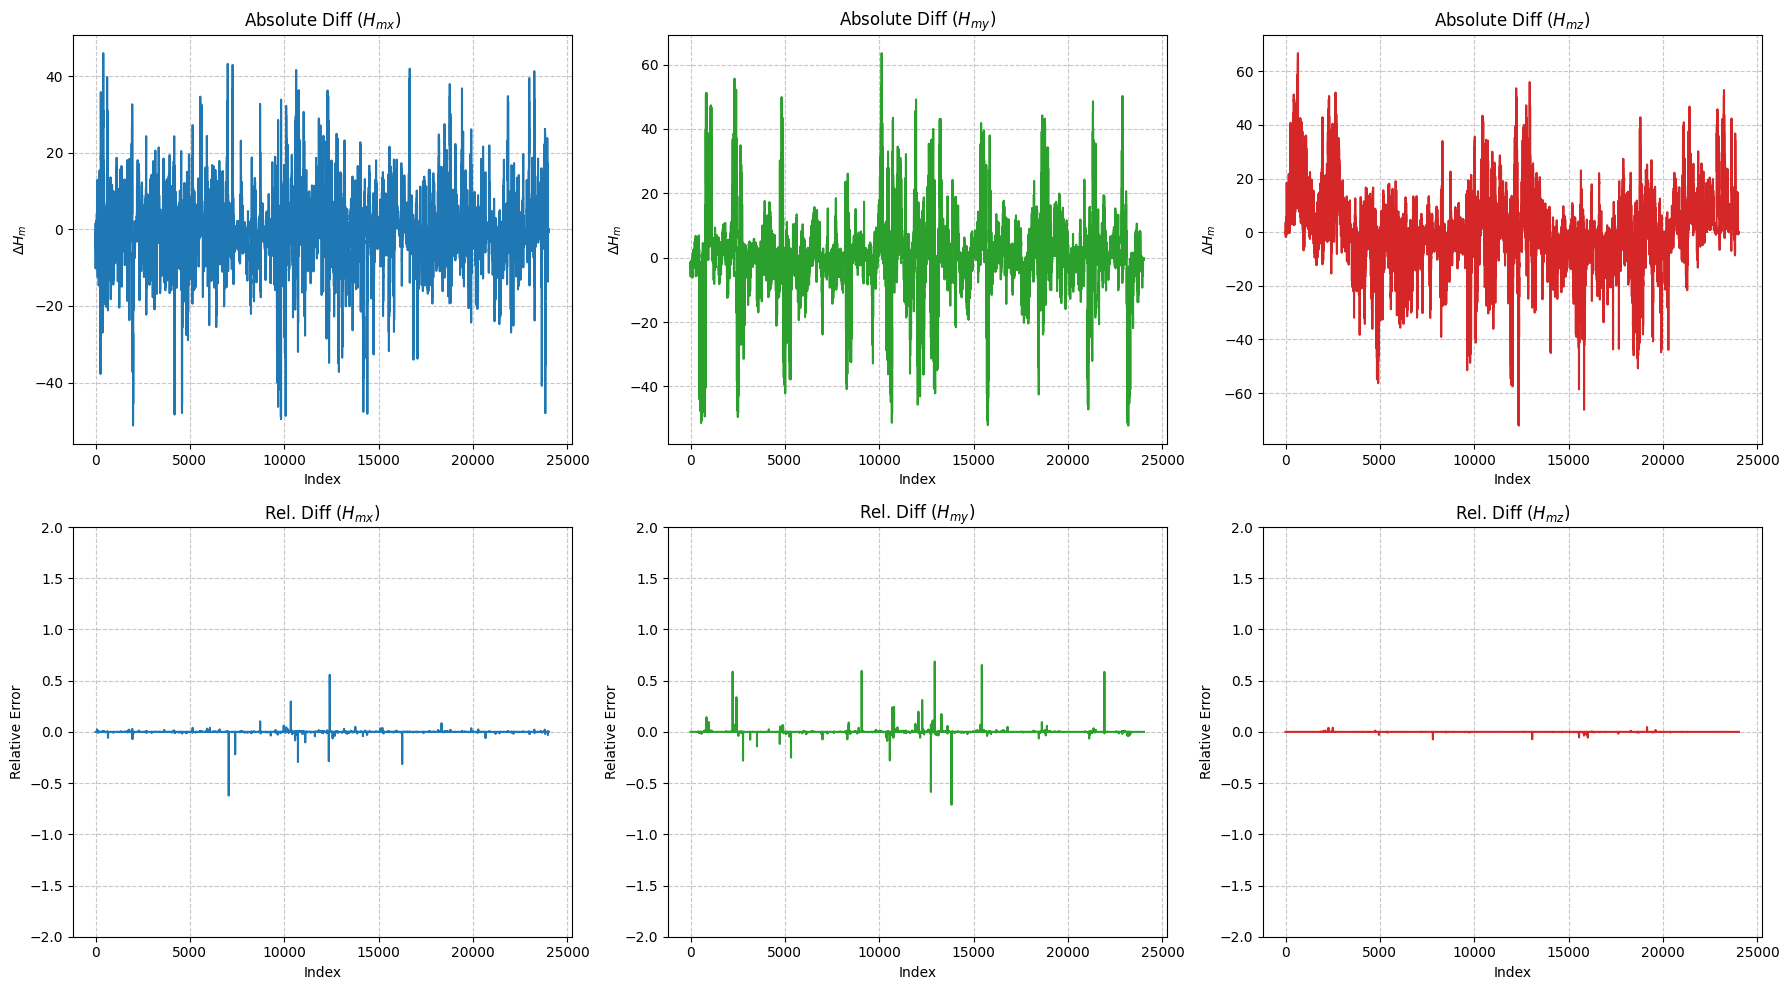

In [307]:
# 2. Calculate Differences
# Absolute differences
diff_x = hmx_fmm - hmx_cuda
diff_y = hmy_fmm - hmy_cuda
diff_z = hmz_fmm - hmz_cuda

# Relative differences (using CUDA as reference)
# Small epsilon added to avoid division by zero
eps = 1e-15 
rel_diff_x = diff_x / (np.abs(hmx_cuda) + eps)
rel_diff_y = diff_y / (np.abs(hmy_cuda) + eps)
rel_diff_z = diff_z / (np.abs(hmz_cuda) + eps)

# 3. Create Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Top Row: Absolute Differences ---
axes[0, 0].plot(diff_x, color='tab:blue')
axes[0, 0].set_title('Absolute Diff ($H_{mx}$)')

axes[0, 1].plot(diff_y, color='tab:green')
axes[0, 1].set_title('Absolute Diff ($H_{my}$)')

axes[0, 2].plot(diff_z, color='tab:red')
axes[0, 2].set_title('Absolute Diff ($H_{mz}$)')

for ax in axes[0, :]:
    ax.set_ylabel('$\Delta H_m$')
    ax.grid(True, linestyle='--', alpha=0.7)

# --- Bottom Row: Relative Differences ---
axes[1, 0].plot(rel_diff_x, color='tab:blue')
axes[1, 0].set_title('Rel. Diff ($H_{mx}$)')

axes[1, 1].plot(rel_diff_y, color='tab:green')
axes[1, 1].set_title('Rel. Diff ($H_{my}$)')

axes[1, 2].plot(rel_diff_z, color='tab:red')
axes[1, 2].set_title('Rel. Diff ($H_{mz}$)')

for ax in axes[1, :]:
    ax.set_ylim(-2, 2)  # Limit range as requested
    ax.set_ylabel('Relative Error')
    ax.grid(True, linestyle='--', alpha=0.7)

# Common labels
for ax in axes.flat:
    ax.set_xlabel('Index')

plt.tight_layout()
plt.savefig('Hm_Comparison_Plot.png', dpi=300)
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_287436/4099248855.py:28: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta H_m$')


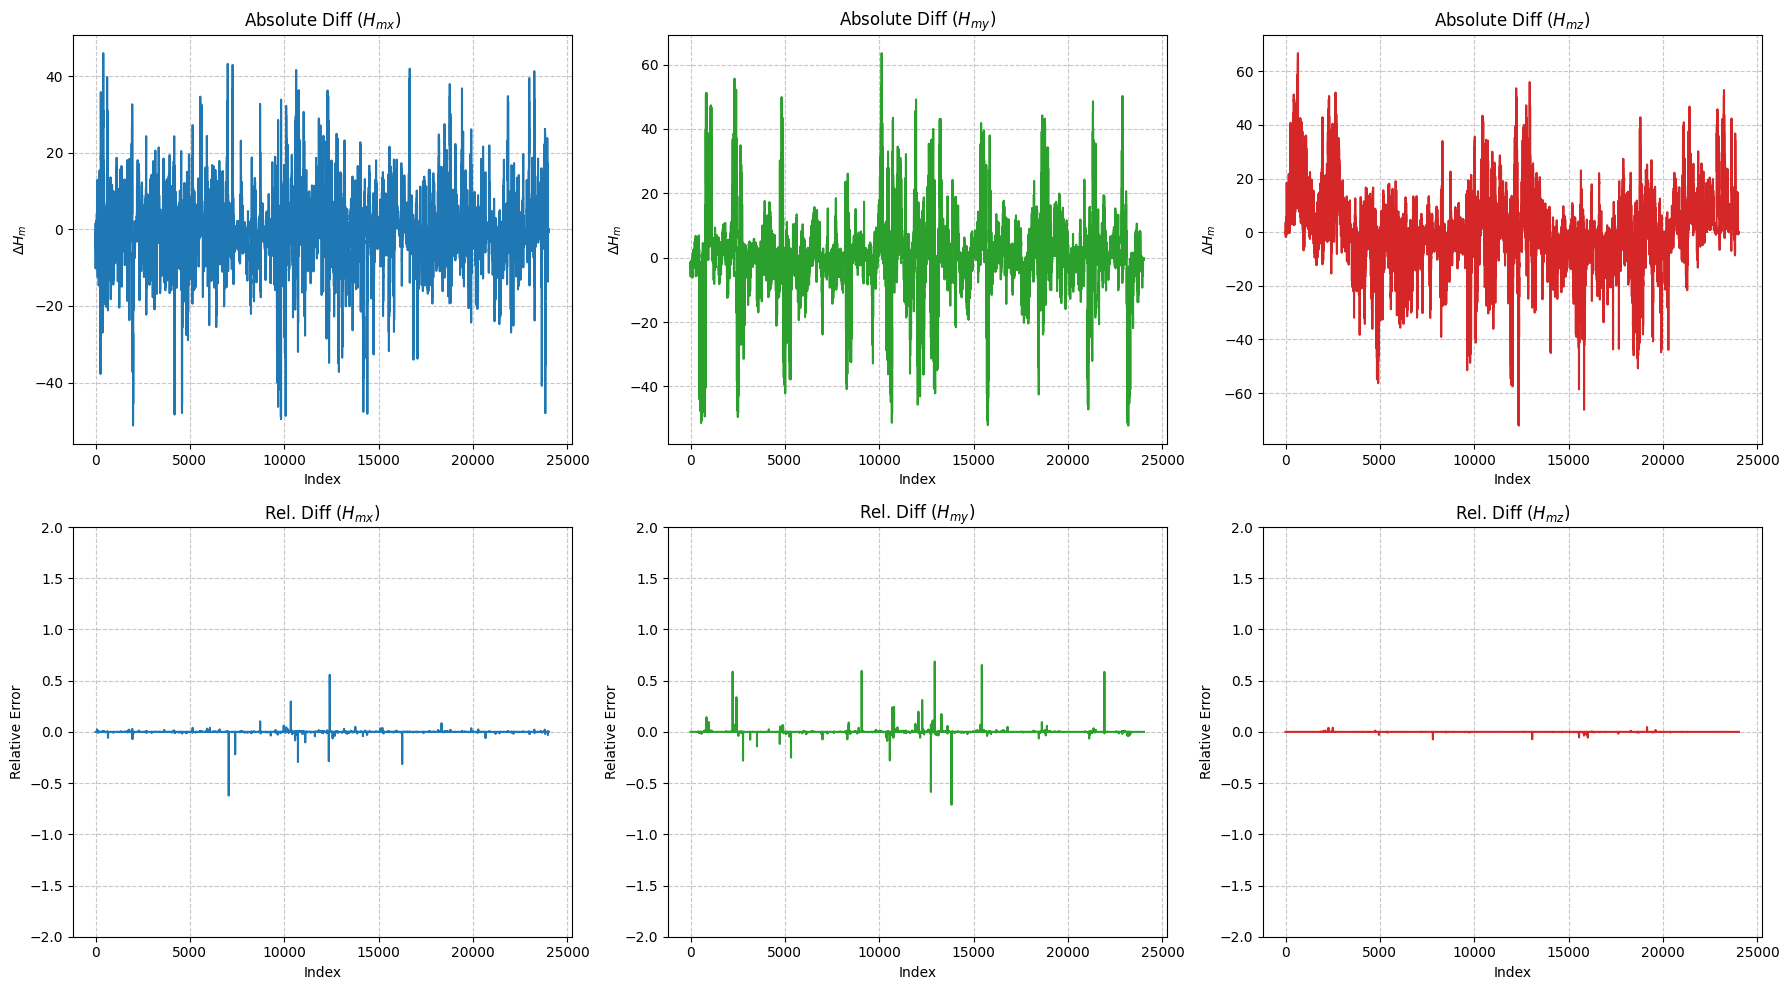

In [308]:
# 2. Calculate Differences
# Absolute differences
diff_x = hmx_fmm - hmx_cuda
diff_y = hmy_fmm - hmy_cuda
diff_z = hmz_fmm - hmz_cuda

# Relative differences (using CUDA as reference)
# Small epsilon added to avoid division by zero
eps = 1e-15 
rel_diff_x = diff_x / (np.abs(hmx_cuda) + eps)
rel_diff_y = diff_y / (np.abs(hmy_cuda) + eps)
rel_diff_z = diff_z / (np.abs(hmz_cuda) + eps)

# 3. Create Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Top Row: Absolute Differences ---
axes[0, 0].plot(diff_x, color='tab:blue')
axes[0, 0].set_title('Absolute Diff ($H_{mx}$)')

axes[0, 1].plot(diff_y, color='tab:green')
axes[0, 1].set_title('Absolute Diff ($H_{my}$)')

axes[0, 2].plot(diff_z, color='tab:red')
axes[0, 2].set_title('Absolute Diff ($H_{mz}$)')

for ax in axes[0, :]:
    ax.set_ylabel('$\Delta H_m$')
    ax.grid(True, linestyle='--', alpha=0.7)

# --- Bottom Row: Relative Differences ---
axes[1, 0].plot(rel_diff_x, color='tab:blue')
axes[1, 0].set_title('Rel. Diff ($H_{mx}$)')

axes[1, 1].plot(rel_diff_y, color='tab:green')
axes[1, 1].set_title('Rel. Diff ($H_{my}$)')

axes[1, 2].plot(rel_diff_z, color='tab:red')
axes[1, 2].set_title('Rel. Diff ($H_{mz}$)')

for ax in axes[1, :]:
    ax.set_ylim(-2, 2)  # Limit range as requested
    ax.set_ylabel('Relative Error')
    ax.grid(True, linestyle='--', alpha=0.7)

# Common labels
for ax in axes.flat:
    ax.set_xlabel('Index')

plt.tight_layout()
plt.savefig('Hm_Comparison_Plot.png', dpi=300)
plt.show()